# LBM-Suite2p-Python: Quickstart

LBM-Suite2p-Python is a volumetric wrapper around [Suite2p](https://suite2p.readthedocs.io/en/latest/) optimized for Light Beads Microscopy data.

## Supported Input Formats

| Format | Extension | Description |
|--------|-----------|-------------|
| TIFF | `.tif`, `.tiff` | Planar timeseries (T, Y, X) |
| Zarr | `.zarr` | Chunked array format |
| Suite2p Binary | `.bin` | Pre-converted binary with `ops.npy` |

**Note:** Raw ScanImage TIFFs must first be assembled using [mbo_utilities](https://millerbrainobservatory.github.io/mbo_utilities/assembly.html).

## Installation

```bash
pip install lbm-suite2p-python
# or from source:
pip install git+https://github.com/MillerBrainObservatory/LBM-Suite2p-Python.git
```

In [1]:
from pathlib import Path
import numpy as np
import mbo_utilities as mbo
import lbm_suite2p_python as lsp

---

## 1. Prepare Input Files


In [2]:
# Path to with planar data files
data_dir = Path(r"D:\example_extraction\zarr")

In [3]:
### Option A: Zarr files (recommended)
input_files = list(data_dir.glob("*.zarr"))
input_files

[WindowsPath('D:/example_extraction/zarr/plane01_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane02_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane03_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane04_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane05_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane06_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane07_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane08_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane09_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane10_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane11_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane12_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane13_stitched.zarr'),
 WindowsPath('D:/example_extraction/zarr/plane14_stitched.zarr')]

In [4]:
# mbo.get_files() works well to gather all TIFF files
# input_files = mbo.get_files(data_dir, str_contains="tif", max_depth=2)
# print(f"Found {len(input_files)} TIFF files:")
# for f in input_files[:3]:
#     print(f"  {f}")
# if len(input_files) > 3:
#     print(f"  ... and {len(input_files) - 3} more")

### Option C: Pre-existing Suite2p binaries

If you have already converted data to Suite2p binary format (e.g., from a previous `mbo.imwrite()` call):

In [5]:
# For pre-existing binaries with ops.npy
# input_files = mbo.get_files(data_dir, str_contains="data_raw.bin", max_depth=2)

---

## 2. Configure Parameters

The `ops` dictionary controls all Suite2p and Cellpose parameters. You only need to specify values you want to override from defaults.

In [6]:
# For Cellpose anatomical detection (recommended for LBM data)
ops = {
    "diameter": 4,                   # Expected cell diameter (pixels)
}

# Where to save results
save_path = Path(r"D:\example_extraction\zarr\suite2p")

---

## 3a. Process a Single Plane: `run_plane()`

Use `run_plane()` to process one z-plane. This is useful for:
- Testing parameters before full volume processing
- Processing individual planes of interest

In [7]:
# View function signature
help(lsp.run_plane)

Help on function run_plane in module lbm_suite2p_python.run_lsp:

run_plane(input_path: str | pathlib.Path, save_path: str | pathlib.Path | None = None, ops: dict | str | pathlib.Path = None, chan2_file: str | pathlib.Path | None = None, keep_raw: bool = False, keep_reg: bool = True, force_reg: bool = False, force_detect: bool = False, dff_window_size: int = 300, dff_percentile: int = 20, save_json: bool = False, **kwargs) -> pathlib.Path
    Processes a single imaging plane using suite2p, handling registration, segmentation,
    and plotting of results.

    Parameters
    ----------
    input_path : str or Path
        Full path to the file to process, with the file extension.
    save_path : str or Path, optional
        Directory to save the results.
    ops : dict, str or Path, optional
        Path to or dict of user‐supplied ops.npy. If given, it overrides any existing or generated ops.
    chan2_file : str, optional
        Path to structural / anatomical data used for registra

In [8]:
# Process a single plane
ops_file = lsp.run_plane(
    input_path=input_files[7],       # Z-Plane 8
    save_path=save_path,             # Output directory
    ops=ops,                # Parameter overrides
    keep_raw=False,                  # Delete raw binary to save space
    keep_reg=True,                   # Keep registered binary for GUI viewing
    force_reg=False,                 # Skip registration if already done
    force_detect=False,              # Skip detection if stat.npy exists
)

print(f"Results saved to: {ops_file.parent}")

Importing suite2p packages...
Roi detection skipped, stat.npy already exists for plane 8.
Skipping data_raw.bin write, already exists and passes data validation checks.
Registration skipped - copying data_raw.bin to data.bin...
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
Saved panel TIFF to D:\example_extraction\zarr\suite2p\pc_metrics_panels.tif
Saved metrics CSV to D:\example_extraction\zarr\suite2p\pc_metrics.csv
   Rigid    Avg_NR    Max_NR
0    0.0  0.049321  0.223607
1    0.0  0.032516  0.141421
2    0.0  0.035306  0.141421
3    0.0  0.043026  0.141421
4    0.0  0.048197  0.141421
Plotting results for 377 accepted / 48 rejected ROIs
  Failed to generate quality diagnostics: too many indices for array: array is 1-dimensional, but 2 were indexed
Results saved to: D:\example_extraction\zarr\suite2p


---

## 3b. Process Full Volume: `run_volume()`

Use `run_volume()` to process all z-planes and generate volumetric statistics.

Importing suite2p packages...
ops['roidetect'] is True with no stat.npy file present, proceeding with segmentation/detection for plane 1.


Saving data_raw.bin:   0%|          | 0/8 [00:00<?, ?it/s]

NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 8.96 sec.
Registered 500/1574 in 8.65s
Registered 1000/1574 in 17.35s
Registered 1500/1574 in 26.46s
Registered 1574/1574 in 28.17s
----------- Total 37.98 sec
Registration metrics, 11.12 sec.
----------- ROI DETECTION
Binning movie in chunks of length 13
Binned movie of size [121,534,430] created in 0.63 sec.


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.12.9 
torch version:  	2.9.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




model_type argument is not used in v4.0.1+. Ignoring this argument...


>>>> CELLPOSE finding masks in enhanced_mean_img
!NOTE! diameter set to 4.00 for cell detection with cellpose


...

NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 8.27 sec.
Registered 500/1574 in 9.01s
Registered 1000/1574 in 17.76s
Registered 1500/1574 in 26.48s
Registered 1574/1574 in 28.10s
----------- Total 37.27 sec
Registration metrics, 12.04 sec.
----------- ROI DETECTION
Binning movie in chunks of length 13


model_type argument is not used in v4.0.1+. Ignoring this argument...


Binned movie of size [121,534,430] created in 0.63 sec.
>>>> CELLPOSE finding masks in enhanced_mean_img
!NOTE! diameter set to 4.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is depricated in v4.0.1+


>>>> 314 masks detected, median diameter = 8.67 
Detected 314 ROIs, 13.41 sec
After removing overlaps, 314 ROIs remain
----------- Total 14.48 sec.
----------- EXTRACTION
Masks created, 0.31 sec.
Extracted fluorescence from 314 ROIs in 1574 frames, 0.77 sec.
----------- Total 1.16 sec.
----------- CLASSIFICATION
['compact', 'npix_norm', 'skew']
----------- SPIKE DECONVOLUTION
----------- Total 0.03 sec.
Saved panel TIFF to D:\example_extraction\zarr\suite2p\plane14_stitched\pc_metrics_panels.tif
Saved metrics CSV to D:\example_extraction\zarr\suite2p\plane14_stitched\pc_metrics.csv
   Rigid    Avg_NR    Max_NR
0    0.0  0.029558  0.141421
1    0.0  0.036701  0.141421
2    0.0  0.030544  0.141421
3    0.0  0.036292  0.141421
4    0.0  0.047619  0.200000
Plotting results for 259 accepted / 55 rejected ROIs
  Failed to generate quality diagnostics: too many indices for array: array is 1-dimensional, but 2 were indexed
Completed plane14_stitched.zarr -> D:\example_extraction\zarr\suite2p\p

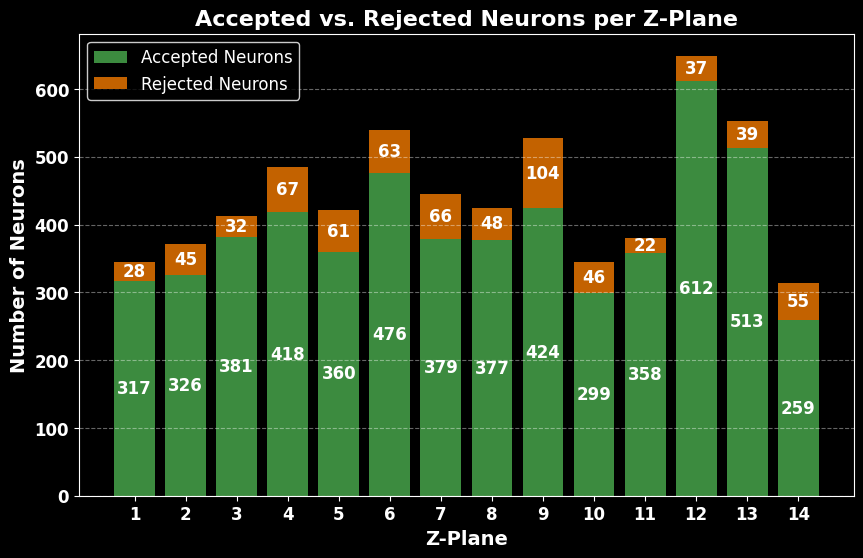

In [9]:
# Process entire volume
output_ops = lsp.run_volume(
    input_files=input_files,         # List of all plane files
    save_path=save_path,             # Output directory
    ops=ops,                # Parameter overrides
    keep_raw=False,                  # Delete raw binaries
    keep_reg=True,                   # Keep registered binaries
    force_reg=False,                 # Skip if already registered
    force_detect=False,              # Skip if already detected
)

print(f"Processed {len(output_ops)} planes")

---

## 4. Output Files

Each plane directory contains standard Suite2p outputs plus additional visualizations:

In [10]:
from pprint import pprint

# List output files
output_files = sorted(save_path.rglob("*.*"))
print("Output files:")
pprint([f.relative_to(save_path) for f in output_files[:20]])

Output files:
[WindowsPath('all_neurons_5499acc_713rej.png'),
 WindowsPath('data.bin'),
 WindowsPath('F.npy'),
 WindowsPath('Fneu.npy'),
 WindowsPath('iscell.npy'),
 WindowsPath('max_projection_image.png'),
 WindowsPath('mean_image.png'),
 WindowsPath('mean_image_enhanced.png'),
 WindowsPath('mean_volume_signal.png'),
 WindowsPath('model.npy'),
 WindowsPath('ops.npy'),
 WindowsPath('pc_metrics.csv'),
 WindowsPath('pc_metrics_panels.tif'),
 WindowsPath('plane01_stitched/data.bin'),
 WindowsPath('plane01_stitched/F.npy'),
 WindowsPath('plane01_stitched/Fneu.npy'),
 WindowsPath('plane01_stitched/iscell.npy'),
 WindowsPath('plane01_stitched/max_projection_image.png'),
 WindowsPath('plane01_stitched/mean_image.png'),
 WindowsPath('plane01_stitched/mean_image_enhanced.png')]


### Standard Suite2p Files

| File | Description |
|------|-------------|
| `ops.npy` | Parameters and processing metadata |
| `stat.npy` | ROI definitions (coordinates, shape stats) |
| `F.npy` | Raw fluorescence traces (n_rois × n_frames) |
| `Fneu.npy` | Neuropil fluorescence traces |
| `spks.npy` | Deconvolved spike estimates |
| `iscell.npy` | Cell classification [is_cell, probability] |
| `data.bin` | Registered movie (if `keep_reg=True`) |

### Additional Outputs

| File | Description |
|------|-------------|
| `max_projection_image.png` | Maximum intensity projection |
| `mean_image.png` | Temporal mean image |
| `segmentation_*.png` | ROI masks overlaid on reference image |
| `traces_*.png` | Sample fluorescence traces |
| `pc_metrics/` | Registration quality metrics (if >1500 frames) |

---

## 5. Load and Analyze Results

In [11]:
# Find ops files
ops_files = mbo.get_files(save_path, str_contains="ops.npy", max_depth=3)
print(f"Found {len(ops_files)} processed planes")

# Load results from first plane
if ops_files:
    results = lsp.load_planar_results(ops_files[0])

    print(f"\nPlane results:")
    print(f"  Total ROIs: {len(results['stat'])}")
    print(f"  Accepted cells: {results['iscell'].sum()}")
    print(f"  Frames: {results['F'].shape[1]}")
    print(f"  F shape: {results['F'].shape}")

Found 15 processed planes

Plane results:
  Total ROIs: 345
  Accepted cells: 317
  Frames: 1574
  F shape: (345, 1574)


### Calculate ΔF/F

In [12]:
# Calculate ΔF/F with rolling percentile baseline
if ops_files:
    dff = lsp.dff_rolling_percentile(
        results['F'],
        window_size=300,    # frames (~10× tau × fs)
        percentile=20       # baseline percentile
    )

    # Filter for accepted cells only
    dff_cells = dff[results['iscell']]
    print(f"ΔF/F shape (accepted cells): {dff_cells.shape}")

ΔF/F shape (accepted cells): (317, 1574)


---

## 6. Open Suite2p GUI

The Suite2p GUI provides interactive visualization and manual curation:

- **View registered movie**: Suite2p → Registration → View Registration Binary
- **Compare raw vs registered**: Check "View raw binary" (requires `keep_raw=True`)
- **Registration quality**: Suite2p → Registration → View Registration Metrics (>1500 frames)

In [13]:
# Open GUI for manual curation
run_gui = False
if ops_files and run_gui:
    stat_file = ops_files[0].parent / "stat.npy"
    if stat_file.exists():
        from suite2p import gui
        gui.run(statfile=str(stat_file))

---

## 7. Volumetric Analysis

When processing multiple z-planes with `run_volume()`, the pipeline automatically generates publication-quality figures for comprehensive volumetric analysis. You can also generate these manually:

In [14]:
# Load data from all planes for volumetric analysis
all_results = []
for ops_file in ops_files:
    try:
        res = lsp.load_planar_results(ops_file)
        all_results.append(res)
    except Exception as e:
        print(f"Error loading {ops_file}: {e}")

if len(all_results) > 1:
    # Consolidate all planes
    all_stat = np.concatenate([res["stat"] for res in all_results])
    all_iscell = np.vstack([res["iscell"] for res in all_results])
    all_F = np.concatenate([res["F"] for res in all_results], axis=0)
    all_Fneu = np.concatenate([res["Fneu"] for res in all_results], axis=0)

    print(f"Consolidated volume:")
    print(f"  Total ROIs: {len(all_stat)}")
    print(f"  Accepted: {all_iscell[:, 0].sum()}")
    print(f"  Planes: {len(all_results)}")
    print(f"  F shape: {all_F.shape}")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 345 and the array at index 1 has size 425

### Multi-Plane Mask Overview

Visualize detected ROIs across all planes in a single figure:

In [ ]:
# Plot masks from all planes in a grid
if len(all_results) > 1:
    fig = lsp.plot_multiplane_masks(
        suite2p_path=save_path,
        stat=all_stat,
        iscell=all_iscell,
        nrows=3,
        ncols=5,
        save_path=save_path / "all_planes_masks.png"  # Optional: save to file
    )

### Volume Quality Metrics

Generate publication-quality figures showing ROI quality across all planes:

In [ ]:
# Quality metrics: ROI counts, compactness, size distributions
if len(all_results) > 1:
    fig = lsp.plot_plane_quality_metrics(
        stat=all_stat,
        iscell=all_iscell,
        save_path=save_path / "volume_quality_metrics.png",
        style="publication"  # or "dark" for dark background
    )

### Trace Analysis

Comprehensive analysis of fluorescence traces across the volume:

In [ ]:
# Trace analysis: SNR, correlation, activity heatmap
if len(all_results) > 1:
    first_ops = lsp.load_ops(ops_files[0])

    fig, metrics = lsp.plot_trace_analysis(
        F=all_F,
        Fneu=all_Fneu,
        stat=all_stat,
        iscell=all_iscell,
        ops=first_ops,
        save_path=save_path / "volume_trace_analysis.png"
    )

    # Access computed metrics
    print(f"Mean SNR across volume: {np.mean(metrics['snr']):.2f}")
    print(f"Cells with SNR > 2: {np.sum(metrics['snr'] > 2)} ({100*np.mean(metrics['snr'] > 2):.1f}%)")

### Summary Statistics Table

Generate a comprehensive summary table for all planes:

In [ ]:
# Create summary table with per-plane statistics
if len(all_results) > 1:
    summary_df = lsp.create_volume_summary_table(
        stat=all_stat,
        iscell=all_iscell,
        F=all_F,
        Fneu=all_Fneu,
        ops=first_ops,
        save_path=save_path / "volume_summary.csv"
    )

    # Display the table
    print(summary_df.to_string(index=False))

### Automatic Volumetric Outputs

When using `run_volume()`, these figures are automatically generated in the output directory:

| File | Description |
|------|-------------|
| `all_planes_masks.png` | Grid showing ROIs overlaid on mean images for all planes |
| `volume_quality_metrics.png` | ROI counts, compactness, size, and acceptance rates per plane |
| `volume_trace_analysis.png` | SNR distributions, example traces, correlation matrix, activity heatmap |
| `volume_summary.csv` | Per-plane statistics table (ROIs, SNR, acceptance rate) |
| `mean_volume_signal.png` | Mean signal intensity across z-depth |
| `rastermap.png` | Activity sorted by similarity (requires rastermap package) |

---

## Next Steps

- **Parameter tuning**: See [anatomical_grid_search.ipynb](./anatomical_grid_search.ipynb) for systematic parameter optimization
- **Spike inference**: See [tau_spike_inference_analysis.ipynb](./tau_spike_inference_analysis.ipynb) for tau parameter analysis
- **Volume consolidation**: Use `lsp.consolidate_volume()` to merge results from all planes into a single directory
- **Documentation**: See the [User Guide](https://millerbrainobservatory.github.io/LBM-Suite2p-Python/user_guide.html) for detailed parameter explanations